<a href="https://colab.research.google.com/github/Arsenii-S7/stepik-DS-ML/blob/main/%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_DS_%D0%B8_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Тема 1.4: Pandas и DataFrame (Нет, панды ни при чем!)

### 💡 Что такое Pandas?
**Pandas** — это главная библиотека Python для анализа данных. Название происходит не от животных, а от термина **«PANel DAta»** (эконометрический термин для наборов данных).

---

### 📑 Основные структуры данных

1. **Series** — одномерный массив (как одна колонка в таблице или список).
2. **DataFrame** — двумерная таблица (состоит из нескольких Series). Это база для работы с данными.

---

### 🛠 Базовые команды для выживания


| Команда | Что делает |
| :--- | :--- |
| `df.head(n)` | Показывает первые `n` строк (по умолчанию 5) |
| `df.tail(n)` | Показывает последние `n` строк |
| `df.shape` | Выдает кортеж `(строк, колонок)` |
| `df.columns` | Показывает названия всех столбцов |
| `df.info()` | Полная сводка: типы данных, память и пропуски |
| `df.describe()` | Статистика: среднее, минимум, максимум и т.д. |

---

### 🔍 Выбор данных: loc vs iloc
*   **`df.iloc[...]`** — поиск по **индексам** (позициям). Работает как обычные срезы в Python.
*   **`df.loc[...]`** — поиск по **названиям** (лейблам). *Важно:* здесь правая граница включается!

---

### 🧩 Типы данных (dtypes)
Чтобы узнать, сколько колонок каждого типа в таблице:
```python
# Современный способ (взамен устаревшего get_dtype_counts)
df.dtypes.value_counts()
```

---
*«Данные — это новая нефть, а Pandas — твой нефтеперерабатывающий завод.»* 🚀


In [5]:
import pandas as pd
import numpy as np

student_performance = pd.read_csv('https://stepik.org/media/attachments/course/4852/StudentsPerformance.csv')

# student_performance # выводит вес dataframe
student_performance.head(10) # выводит первые n строк (начало с 0 индекса)




,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [6]:
# Сгенерировать описательную статистику.
student_performance.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
# Возвращает типы данных из DataFrame.
student_performance.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [8]:
# Возвращает кортеж, представляющий размерность DataFrame.
student_performance.shape

(1000, 8)

In [9]:
# Возвращает целое число, представляющее количество элементов в этом объекте.
student_performance.size

8000

In [10]:
# первым указывается количество строк (не включительно)
student_performance.iloc[0:4]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44


In [11]:
#добавляем лимит для столбцов (не включительно)
student_performance.iloc[0:4, 0:3]

,gender,race/ethnicity,parental level of education
0,female,group B,bachelor's degree
1,female,group C,some college
2,female,group B,master's degree
3,male,group A,associate's degree


In [12]:
# Наглядность во всем: можем одновременно выцепить конкретные строки и колонки с конца,
# просто передав списки индексов. Никакой путаницы, всё максимально прозрачно.
student_performance.iloc[[0, 3, 10], [-1, -2, -3]]



,writing score,reading score,math score
0,74,72,72
3,44,57,47
10,52,54,58


In [13]:

student_performance_with_names = student_performance.iloc[[0,3,4,7,8]]
student_performance_with_names

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67


In [14]:
# присвоим конкретный индекс каждому студенту (имя)

student_performance_with_names.index = ["Cersei", "Tywin", "Gregor", "Joffrey", "Ilyn Payne"]
student_performance_with_names


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
Cersei,female,group B,bachelor's degree,standard,none,72,72,74
Tywin,male,group A,associate's degree,free/reduced,none,47,57,44
Gregor,male,group C,some college,standard,none,76,78,75
Joffrey,male,group B,some college,free/reduced,none,40,43,39
Ilyn Payne,male,group D,high school,free/reduced,completed,64,64,67


In [15]:
# Доступ к группе строк и столбцов осуществляется по меткам или логическому массиву.
student_performance_with_names.loc[["Cersei", "Tywin"]]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
Cersei,female,group B,bachelor's degree,standard,none,72,72,74
Tywin,male,group A,associate's degree,free/reduced,none,47,57,44


In [16]:
student_performance_with_names.loc[["Cersei", "Tywin"], ['gender', 'lunch']]


,gender,lunch
Cersei,female,standard
Tywin,male,free/reduced


In [17]:
type(student_performance_with_names.loc[["Cersei", "Tywin"], ['gender', 'lunch']]) #pandas.core.frame.DataFrame

pandas.core.frame.DataFrame

In [18]:
type(student_performance_with_names.iloc[:, 0]) #pandas.core.series.Series


pandas.core.series.Series

In [19]:
# Создание pandas.Series

pd.Series([1,2,3])

,0
0,1
1,2
2,3


In [20]:
pd.Series([1,2,3], index = ['a', 'b', 'c'])

,0
a,1
b,2
c,3


In [21]:
# создание своего DataFrame
my_series1 = pd.Series([1,2,3], index = ['a', 'b', 'c'])
my_series2 = pd.Series([4,5,6], index = ['a', 'b', 'c'])
pd.DataFrame({'col_name1': my_series1, 'col_name2': my_series2})

,col_name1,col_name2
a,1,4
b,2,5
c,3,6


In [22]:
# получаем DataFrame
student_performance_with_names[['gender']]


,gender
Cersei,female
Tywin,male
Gregor,male
Joffrey,male
Ilyn Payne,male


In [23]:
# получаем Series

student_performance_with_names['gender']


,gender
Cersei,female
Tywin,male
Gregor,male
Joffrey,male
Ilyn Payne,male


# 🚢 Практика: Разведка данных (Dataset: Titanic)

Когда мы получаем новый датасет, первым делом нужно понять его структуру. Вот базовый набор команд для "первого знакомства" с данными:

---

### 🔍 1. Узнаем размер таблицы
Чтобы ответить на вопросы о количестве строк и колонок, используем атрибут `.shape`.
```python
df.shape  # Возвращает (строки, колонки)
```

### 📊 2. Считаем типы данных
Для заполнения пропусков по типам (`float`, `int`, `object`) идеально подходит связка, которую мы обсуждали ранее:
```python
# Показывает, сколько колонок каждого типа в датасете
df.dtypes.value_counts()
```

### 📋 3. Быстрая сводка (Всё и сразу)
Если нужно увидеть и пропуски, и типы, и память — используем один метод:
```python
df.info()
```
*В ответе `info()` в верхней строке будет общее кол-во строк, а ниже — список всех колонок с их типами.*

---

### 💡 Лайфхак для задания:
1. Количество **строк** и **колонок** — смотри `df.shape`.
2. Количество колонок типа **float**, **int** и **object** — смотри `df.dtypes.value_counts()`.

> **Pandas удобен тем, что за секунду дает полное представление о данных, даже если в них тысячи строк.**


In [24]:
titanic_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/titanic.csv')
# Узнаем размер таблицы
titanic_data.shape

(891, 12)

In [25]:
# Считаем типы данных
# df.types.value_counts возвращает объект Series, содержащий частоту встречаемости каждой уникальной строки в DataFrame.
titanic_data.dtypes.value_counts()

,count
int64,5
object,5
float64,2


# 🔍 Тема 1.5: Фильтрация данных в Pandas

Фильтрация позволяет выцепить из огромной таблицы только те строки, которые подходят под наше условие.

---

### 🧱 Базовый синтаксис
Самый простой способ отфильтровать данные — передать условие в квадратных скобках:
```python
# Выбрать студентов, у которых балл по письму > 90
high_scorers = df[df['writing score'] > 90]
```

### 🧬 Несколько условий (Логические операторы)
Когда нужно проверить сразу несколько параметров:
*   **`&` (И)** — должны выполняться оба условия.
*   **`|` (ИЛИ)** — должно выполняться хотя бы одно условие.
*   **`~` (НЕ)** — инверсия (все, кроме тех, кто подошел под условие).

> **Важно:** Каждое условие обязательно берем в **круглые скобки**!

```python
# Пример: Девушки с баллом по письму выше среднего
df[(df['gender'] == 'female') & (df['writing score'] > df['writing score'].mean())]
```

---

### 🛠 Полезные методы для фильтрации

1.  **`.query()`** — позволяет писать условия в виде строки (очень читаемо).
    ```python
    df.query("gender == 'female' & `writing score` > 90")
    ```
    *(Если в названии колонки есть пробел, используй обратные кавычки `` ` ``)*

2.  **`.isin()`** — когда нужно проверить вхождение в список значений.
    ```python
    # Выбрать студентов только из групп A и B
    df[df['race/ethnicity'].isin(['group A', 'group B'])]
    ```

---

### 💡 Почему это удобно?
Фильтрация в Pandas — это **декларативный** подход. Ты не пишешь цикл `for`, чтобы проверить каждую строку, ты просто говоришь: «Дай мне тех, у кого...». Это работает в десятки раз быстрее и выглядит чище.

---
**Шпаргалка для тестов:**
- `==` — проверка на равенство.
- `!=` — проверка на неравенство.
- Срез через `df[df.column > 0]` возвращает **копию** или **view** данных, подходящих под условие.


In [26]:
import pandas as pd

student_performance = pd.read_csv('https://stepik.org/media/attachments/course/4852/StudentsPerformance.csv')
student_performance.head()



,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
student_performance.gender == 'female'

,gender
0,True
1,True
2,True
3,False
4,False
...,...
995,True
996,False
997,True
998,True


# 🏋️‍♂️ Практика: Задачи на фильтрацию (Dataset: StudentsPerformance)

*Для выполнения заданий используй датасет: `https://stepik.org`*

---

### 🥊 Задание 1: Клуб отличников
**Цель:** Отфильтровать самых сильных студентов.
**Условие:** Балл по математике (`math score`) **> 90** И балл по чтению (`reading score`) **>= 85**.

### 🛠 Задание 2: Талант без подготовки
**Цель:** Найти тех, кто справился сам.
**Условие:** Курс подготовки (`test preparation course`) равен **'none'**, но балл по письму (`writing score`) **> 95**.

### 👨‍👩‍👧‍👦 Задание 3: Специфические группы
**Цель:** Попрактиковаться в выборе по списку.
**Условие:** Студенты относятся только к **'group A'** или **'group E'**.
*(Совет: используй метод `.isin()`)*

### 📝 Задание 4: Битва навыков (через `.query()`)
**Цель:** Сравнить две колонки между собой.
**Условие:** Девушки (`gender == 'female'`), у которых балл по чтению **выше**, чем балл по математике.

---
> **💡 Лайфхак:** Не забывай, что в методе `.query()` названия колонок с пробелами нужно брать в обратные кавычки: `` `writing score` ``.


In [28]:
# 🥊 Задание 1: Клуб отличников

best_students = student_performance.loc[(student_performance['math score']>90) & (student_performance['reading score'] >= 85)]
best_students

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
34,male,group E,some college,standard,none,97,87,82
104,male,group C,some college,standard,completed,98,86,90
114,female,group E,bachelor's degree,standard,completed,99,100,100
121,male,group B,associate's degree,standard,completed,91,89,92
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
171,male,group E,some high school,standard,none,94,88,78
179,female,group D,some high school,standard,completed,97,100,100
233,male,group E,some high school,standard,none,92,87,78
263,female,group E,high school,standard,none,99,93,90


In [131]:
#🛠 Задание 2: Талант без подготовки
# df.columns = [x.replace(' ', '_') for x in df.columns]
# student_performance.columns = [x.replace(' ', '_') for x in student_performance.columns]
wonderkind_student = student_performance.loc[(student_performance['test_preparation_course'] == 'none') & (student_performance['writing_score'] > 95)]
print(wonderkind_student)

     gender race/ethnicity parental_level_of_education     lunch  \
106  female        group D             master's degree  standard   
451  female        group E                some college  standard   
458  female        group E           bachelor's degree  standard   
580  female        group D            some high school  standard   
712  female        group D                some college  standard   
855  female        group B           bachelor's degree  standard   
941  female        group D             master's degree  standard   
957  female        group D             master's degree  standard   
962  female        group E          associate's degree  standard   
970  female        group D           bachelor's degree  standard   

    test_preparation_course  math_score  reading_score  writing_score  \
106                    none          87            100            100   
451                    none         100             92             97   
458                    none     

In [ ]:
# какой доли студентов из датасэта  в колонке lunch указано free/reduced?
# Формат ответа десятичная дробь, например, 0.25
free_reduced_st = student_performance.loc[student_performance['lunch'] == 'free/reduced']
# Берём количество строк из отфильтрованного DF и делим на общее число строк
result = free_reduced_st.shape[0] / student_performance.shape[0]
print(result)


In [ ]:

# Как различается среднее и дисперсия оценок по предметам
# у групп студентов со стандартным или урезанным ланчем?


stand_lunch = student_performance.loc[student_performance['lunch'] == 'standard']
free_lunch = student_performance.loc[student_performance['lunch'] == 'free/reduced']
mean_st_luch = stand_lunch[['math score', 'reading score', 'writing score']].mean()
mean_fr_luch = free_lunch[['math score', 'reading score', 'writing score']].mean()

print(mean_st_luch)
print(mean_fr_luch)

var_st_luch = stand_lunch[['math score', 'reading score', 'writing score']].var()
var_fr_luch = free_lunch[['math score', 'reading score', 'writing score']].var()

print(var_st_luch)
print(var_fr_luch)



In [ ]:
# Сначала выбираем нужные колонки, а потом группируем
stats = student_performance.groupby('lunch')[['math score', 'reading score', 'writing score']].agg(['mean', 'var'])
print(stats)

# 🏷️ Переименование колонок в Pandas

Чтобы код был чистым и к колонкам можно было обращаться через точку (например, `df.math_score`), в названиях не должно быть пробелов.

---

### Способ 1: Метод `.rename()`
Мы передаем словарь, где ключ — старое имя, а значение — новое.
```python
df = df.rename(columns={
    'math score': 'math_score',
    'reading score': 'reading_score'
})
```
*   ✅ **Плюсы:** Можно переименовать только одну-две конкретные колонки, не трогая остальные.
*   ❌ **Минусы:** Много ручной печати. Если колонок 50, ты устанешь писать словарь.

---

### Способ 2: Массовая замена (Python-стиль) 🚀
Если нужно во всех названиях заменить пробелы на нижнее подчеркивание.
```python
df.columns = [x.replace(' ', '_') for x in df.columns]
```
*   ✅ **Плюсы:** Одна строка кода обрабатывает таблицу любого размера.
*   ❌ **Минусы:** Переименует вообще всё, даже если ты хотел оставить пробел в какой-то одной колонке.

---

### Способ 3: Через метод `.str` (Самый эффективный)
Это "пандосский" способ работы со строками в названиях.
```python
df.columns = df.columns.str.replace(' ', '_')
```
*   ✅ **Плюсы:** Самый быстрый и читаемый метод. Работает мгновенно на огромных данных.
*   🥇 **Эффективность:** Это лучший выбор для Data Science проектов.

---

### 📊 Сравнение эффективности


| Метод | Когда использовать? | Скорость написания |
| :--- | :--- | :--- |
| **.rename()** | Нужно точечно изменить 1-3 имени | 🐢 Медленно |
| **List comprehension** | Универсальный способ Python | ⚡ Быстро |
| **.str.replace()** | Идеально для массовой чистки данных | 🚀 Мгновенно |

**💡 Совет:** Если ты ленивый (в хорошем смысле) программист — используй Способ №3. Это сэкономит время и избавит от опечаток в длинных словарях!


In [34]:
student_performance.columns = [x.replace(' ', '_') for x in student_performance.columns ]
student_performance.query('writing_score > 70')

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
...,...,...,...,...,...,...,...,...
992,female,group D,associate's degree,free/reduced,none,55,76,76
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
995,female,group E,master's degree,standard,completed,88,99,95
998,female,group D,some college,standard,completed,68,78,77


In [35]:
student_performance.query("gender == 'feamle' | reading_score > 90")

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
2,female,group B,master's degree,standard,none,90,95,93
6,female,group B,some college,standard,completed,88,95,92
102,female,group D,associate's degree,standard,none,85,91,89
106,female,group D,master's degree,standard,none,87,100,100
114,female,group E,bachelor's degree,standard,completed,99,100,100
...,...,...,...,...,...,...,...,...
957,female,group D,master's degree,standard,none,92,100,100
962,female,group E,associate's degree,standard,none,100,100,100
970,female,group D,bachelor's degree,standard,none,89,100,100
979,female,group C,associate's degree,standard,none,91,95,94


# 🔍 Фильтрация колонок (Select Columns)

Иногда нам нужно выбрать не строки, а конкретные столбцы, названия которых подходят под условие.

---

### Способ 1: List Comprehension (Как на видео)
Мы проходим циклом по всем именам колонок и оставляем только те, где есть слово `'score'`.
```python
score_columns = [i for i in list(df) if 'score' in i]
df[score_columns].head()
```
*   ✅ **Плюсы:** Чистый Python, очень гибкий (можно задать любое сложное условие).
*   ❌ **Минусы:** Длинный код, нужно создавать промежуточный список.

---

### Способ 2: Метод `.filter()` (Самый удобный) 🚀
Специальный метод Pandas для быстрого поиска колонок по названию.
```python
# Найти все колонки, в названии которых есть слово 'score'
df.filter(like='score')
```
*   ✅ **Плюсы:** Очень коротко и понятно. Идеально для быстрой разведки данных.
*   🥇 **Эффективность:** Это самый быстрый способ для повседневных задач.

---

### Способ 3: Регулярные выражения (Для профи) 🧬
Если нужно найти колонки по сложному шаблону (например, начинаются на "math" или заканчиваются на "score").
```python
# Выберет колонки, которые заканчиваются на 'score'
df.filter(regex='score$')
```

---

### 📊 Сравнение методов поиска колонок


| Метод | Что делает | Когда использовать? |
| :--- | :--- | :--- |
| **List Comprehension** | `[i for i in df if ...]` | Когда нужно очень сложное условие |
| **.filter(like=...)** | Ищет подстроку в названии | Для быстрого поиска (самый частый кейс) |
| **.filter(regex=...)** | Ищет по шаблону (RegEx) | Когда названия очень похожи или их сотни |

---
**💡 Лайфхак:** Метод `.filter()` по умолчанию ищет по колонкам (`axis=1`). Если ты хочешь отфильтровать **строки** по их именам (индексам), просто добавь `axis=0`.


### 🛠️ Глубокое погружение в `.filter()`
Метод `.filter()` не меняет сами данные, он лишь **отбирает** нужные строки или столбцы по их названиям (лейблам).

**Основные параметры (согласно документации):**

1.  **`items`**: когда точно знаешь названия.
    *   `df.filter(items=['math_score', 'writing_score'])` — выберет только эти две колонки.
2.  **`like`**: простой поиск по подстроке.
    *   `df.filter(like='score')` — выберет всё, где есть слово "score".
3.  **`regex`**: мощный поиск по шаблону (регулярным выражениям).
    *   `df.filter(regex='score$')` — только те, что заканчиваются на "score".
4.  **`axis`**: направление поиска.
    *   `axis=1` (или `'columns'`) — ищем среди названий столбцов (**по умолчанию**).
    *   `axis=0` (или `'index'`) — ищем среди названий строк (индексов).

---

### 💡 Почему это важно?
В отличие от обычного обращения `df[['col1', 'col2']]`, метод `.filter()` **не выдаст ошибку**, если какой-то колонки не существует. Он просто пропустит её и выведет то, что нашел. Это делает код более стабильным при работе с динамическими данными.



In [30]:
student_performance.filter(like = 'score')

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75
...,...,...,...
995,88,99,95
996,62,55,55
997,59,71,65
998,68,78,77


In [31]:
score_columns = [i for i in list(student_performance) if 'score' in i]
print(score_columns)
student_performance[score_columns].head()

['math score', 'reading score', 'writing score']


,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [32]:
# 👨‍👩‍👧‍👦 Задание 3: Специфические группы

A_OR_E = student_performance[student_performance['race/ethnicity'].isin(['group E', 'group A'])]
print(A_OR_E)


     gender race/ethnicity parental level of education         lunch  \
3      male        group A          associate's degree  free/reduced   
13     male        group A                some college      standard   
14   female        group A             master's degree      standard   
25     male        group A             master's degree  free/reduced   
32   female        group E             master's degree  free/reduced   
..      ...            ...                         ...           ...   
987    male        group E            some high school      standard   
988  female        group A            some high school  free/reduced   
990    male        group E                 high school  free/reduced   
994    male        group A                 high school      standard   
995  female        group E             master's degree      standard   

    test preparation course  math score  reading score  writing score  
3                      none          47             57         

In [36]:
# 📝 Задание 4: Битва навыков

student_performance.query("gender == 'female' & reading_score > math_score")



,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
9,female,group B,high school,free/reduced,none,38,60,50
...,...,...,...,...,...,...,...,...
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
995,female,group E,master's degree,standard,completed,88,99,95
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


#  📊 Тема 1.6:  Группировка и агрегация в Pandas

Группировка данных — это процесс **Split-Apply-Combine**:
1. **Split** — разбиение данных на группы по значению признака.
2. **Apply** — применение функции к каждой группе отдельно.
3. **Combine** — объединение результатов в одну структуру.

---

## 🛠 Основной синтаксис
Самый простой вариант группировки:
```python
df.groupby('column_name')
```
*Примечание: сам по себе `groupby` создает объект-группировщик, к которому нужно применить функцию.*

---

## 📊 Агрегирующие методы
Применяются сразу после группировки:


| Метод | Что делает |
| :--- | :--- |
| `.mean()` | Среднее значение |
| `.sum()` | Сумма |
| `.count()` | Количество (включая NaN) |
| `.size()` | Размер группы (строки) |
| `.min() / .max()` | Минимум / Максимум |
| `.describe()` | Все базовые статистики |

**Пример:**
```python
# Средний возраст пассажиров в зависимости от пола
df.groupby('sex').age.mean()
```

---

## 🧪 Гибкая агрегация с .agg()
Метод `.aggregate()` (сокращенно `.agg()`) позволяет считать несколько метрик за раз.

1. **Несколько функций для одного столбца:**
```python
df.groupby('sex').age.agg(['mean', 'median'])
```

2. **Разные функции для разных столбцов (через словарь):**
```python
df.groupby('sex').agg({
    'age': 'mean',
    'fare': 'sum'
})
```

---

## 🧬 Продвинутые техники

### Группировка по нескольким признакам
Передаем список колонок. На выходе получаем **MultiIndex**.
```python
df.groupby(['pclass', 'sex']).mean()
```

### Сброс индекса (.reset_index)
Чтобы превратить сгруппированный объект обратно в обычный DataFrame (удобно для дальнейшей работы):
```python
df.groupby('sex').age.mean().reset_index()
```

### Сортировка
Часто используется в связке для поиска топов:
```python
df.groupby('genre').revenue.sum().sort_values(ascending=False)
```

---
💡 **Lifehack:** Если нужно посчитать количество уникальных значений в группе, используй `.nunique()`.
```python
df.groupby('category').user_id.nunique()
```


# 📊 Тема: 1.6 Группировка и агрегация (дополнение)

## 🧩 Что такое группировка?

Группировка — это разбиение данных на категории (группы) по значениям одного или нескольких признаков (например, по полу, возрасту, городу). Затем внутри каждой группы применяются **агрегатные функции** — свёртка данных группы в одно число.

> Пример: есть данные о продажах по дням. Группируем по месяцам → для каждого месяца считаем сумму продаж.

## 🧩 Что такое агрегация?

**Агрегация** — это процесс вычисления итоговой характеристики (сумма, среднее, максимум, минимум, количество, стандартное отклонение и т.д.) для каждой группы.

Часто используют связку: **split-apply-combine** (разделили – применили – объединили).

---

## 📋 Часто используемые агрегации

| Агрегация | Что делает | Пример использования |
|-----------|------------|----------------------|
| 🧮 **sum()** | Сумма значений в группе | Суммарные продажи по региону |
| 📊 **mean()** | Среднее арифметическое | Средняя зарплата по отделу |
| 🧐 **median()** | Медиана (50-й процентиль) | Медианный возраст по городу |
| 🔢 **count()** | Количество непустых значений | Сколько клиентов в каждой группе |
| 🔢 **nunique()** | Количество уникальных значений | Сколько разных товаров купил каждый покупатель |
| 🧮 **min()** / **max()** | Минимум / максимум | Самая низкая и высокая температура в месяц |
| 📉 **std()** / **var()** | Стандартное отклонение / дисперсия | Разброс оценок по группам |
| 📐 **sem()** | Стандартная ошибка среднего | Для построения доверительных интервалов |
| 🧮 **prod()** | Произведение значений | — редко, но бывает |
| 📊 **quantile(q)** | Любой квантиль (по умолчанию 0.5 = медиана) | 0.25, 0.75 квартили |

---

## 🧠 Базовые правила

- Группировка чаще всего делается по **категориальным (номинативным или порядковым) переменным**.
- Количественные переменные можно группировать после дискретизации (например, возраст 0–18, 19–35, 36+).
- После группировки мы **теряем индивидуальные наблюдения**, остаются только агрегаты.
- Важно правильно выбирать меру центральной тенденции: для нормальных данных – среднее, для скошенных – медиана.

---

## 🐍 Пример на Python (pandas) — для ячейки с кодом

Если потом захотите вставить в код:

```python
import pandas as pd
df = pd.DataFrame({
    'город': ['A', 'B', 'A', 'B', 'A'],
    'продажи': [100, 200, 150, 250, 120]
})
# Группировка по городу и сумма продаж
grouped = df.groupby('город')['продажи'].sum()
print(grouped)

In [37]:
import pandas as pd
# student_performance = pd.read_csv('https://stepik.org/media/attachments/course/4852/StudentsPerformance.csv')
student_performance.groupby('gender')



In [40]:
student_performance.columns = [x.replace(' ', '-') for x in student_performance.columns]
student_performance.head()
# student_performance.groupby('gender')[['math-core', 'reading-score', 'writing-score']].mean()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [41]:
import pandas as pd

student_performance = pd.read_csv('https://stepik.org/media/attachments/course/4852/StudentsPerformance.csv')

student_performance.columns = [x.replace(' ', '_') for x in student_performance.columns]
student_performance.head()
student_performance.groupby('gender', as_index= False)[['math_score', 'reading_score', 'writing_score']].mean()

,gender,math_score,reading_score,writing_score
0,female,63.633205,72.608108,72.467181
1,male,68.728216,65.473029,63.311203


In [42]:
import pandas as pd

student_performance = pd.read_csv('https://stepik.org/media/attachments/course/4852/StudentsPerformance.csv')
student_performance.head()
mean_scores = student_performance.groupby(['gender','race/ethnicity'])\
.aggregate({'math score': 'mean', 'reading score': 'mean'})

print(mean_scores)


                       math score  reading score
gender race/ethnicity                           
female group A          58.527778      69.000000
       group B          61.403846      71.076923
       group C          62.033333      71.944444
       group D          65.248062      74.046512
       group E          70.811594      75.840580
male   group A          63.735849      61.735849
       group B          65.930233      62.848837
       group C          67.611511      65.424460
       group D          69.413534      66.135338
       group E          76.746479      70.295775


In [43]:
mean_scores.loc[('female', 'group A')]

,female
,group A
math score,58.527778
reading score,69.000000


In [44]:
mean_scores.loc[[('female', 'group A'), ('female', 'group B')]]

math score  reading score
gender race/ethnicity                           
female group A          58.527778      69.000000
       group B          61.403846      71.076923

In [45]:
# метод sort_values
# ascending=False -  меняет порядок сортировки

student_performance.sort_values(['gender', 'math score'], ascending=False )

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
149,male,group E,associate's degree,free/reduced,completed,100,100,93
623,male,group A,some college,standard,completed,100,96,86
625,male,group D,some college,standard,completed,100,97,99
916,male,group E,bachelor's degree,standard,completed,100,100,100
306,male,group E,some college,standard,completed,99,87,81
...,...,...,...,...,...,...,...,...
145,female,group C,some college,free/reduced,none,22,39,33
787,female,group B,some college,standard,none,19,38,32
17,female,group B,some high school,free/reduced,none,18,32,28
980,female,group B,high school,free/reduced,none,8,24,23


In [46]:
# Создание новой колонки
student_performance.columns = [x.replace(' ', '_') for x in student_performance.columns]

student_performance['total_score'] = student_performance.math_score + student_performance.reading_score + student_performance.writing_score
student_performance.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [47]:
import numpy as np

student_performance = student_performance.assign(total_score_log = np.log(student_performance.total_score))
student_performance.head()

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,total_score_log
0,female,group B,bachelor's degree,standard,none,72,72,74,218,5.384495
1,female,group C,some college,standard,completed,69,90,88,247,5.509388
2,female,group B,master's degree,standard,none,90,95,93,278,5.627621
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,4.997212
4,male,group C,some college,standard,none,76,78,75,229,5.433722


In [48]:
# Удаление колонки
student_performance.drop(['total_score'], axis = 1)


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score_log
0,female,group B,bachelor's degree,standard,none,72,72,74,5.384495
1,female,group C,some college,standard,completed,69,90,88,5.509388
2,female,group B,master's degree,standard,none,90,95,93,5.627621
3,male,group A,associate's degree,free/reduced,none,47,57,44,4.997212
4,male,group C,some college,standard,none,76,78,75,5.433722
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,5.641907
996,male,group C,high school,free/reduced,none,62,55,55,5.147494
997,female,group C,high school,free/reduced,completed,59,71,65,5.273000
998,female,group D,some college,standard,completed,68,78,77,5.407172


In [49]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем
# Пересчитаем число ног у героев игры Dota2!
# Сгруппируйте героев из датасэта по числу их ног (колонка legs), и заполните их число в задании ниже.

import pandas as pd

df = pd.read_csv('https://stepik.org/media/attachments/course/4852/dota_hero_stats.csv')

df.head(5)
df.groupby('legs').count()
# df.shape

,Unnamed: 0,attack_type,id,localized_name,name,primary_attr,roles
legs,,,,,,,
0,11,11,11,11,11,11,11
2,95,95,95,95,95,95,95
4,7,7,7,7,7,7,7
6,3,3,3,3,3,3,3
8,1,1,1,1,1,1,1


In [50]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем

# Продолжим исследование героев Dota2. Сгруппируйте
# по колонкам attack_type и primary_attr и выберите самый распространённый набор характеристик.

df.head(5)
df.groupby(['attack_type', 'primary_attr']).size().unstack()

primary_attr,agi,int,str
attack_type,,,
Melee,19,2,35
Ranged,18,40,3


In [51]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем

# К нам поступили данные из бухгалтерии о заработках Лупы и Пупы за разные задачи! Посмотрите у кого из них больше средний заработок в различных категориях (колонка Type)
# и заполните таблицу, указывая исполнителя с большим заработком в каждой из категорий.
import pandas as pd

accountancy = pd.read_csv('https://stepik.org/media/attachments/course/4852/accountancy.csv')

accountancy.head(5)
result = accountancy.groupby(['Type', 'Executor'])['Salary'].mean().unstack()
print(result)



Executor       Loopa        Pupa
Type                            
A          58.000000  160.833333
B         145.166667   77.000000
C         154.333333   74.500000
D         137.714286  146.500000
E         164.000000  131.200000
F         238.000000  136.250000


In [52]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем
import pandas as pd

url = 'http://stepik.org/media/attachments/course/4852/algae.csv'
concentrations = pd.read_csv(url, encoding='utf-8', sep=',')

# Посмотреть, какие колонки есть
# print(concentrations.columns.tolist())
print(concentrations.head())

# Группировка
mean_concentrations = concentrations.groupby('genus').mean(numeric_only=True)
print(mean_concentrations)

               species       genus  group   sucrose    alanin   citrate  \
0    Fucus_vesiculosus       Fucus  brown  3.001472  3.711498  5.004262   
1  Saccharina_japonica  Saccharina  brown  6.731070  1.255251  5.621499   
2       Fucus_serratus       Fucus  brown  3.276870  0.346431  1.216767   
3      Fucus_distichus       Fucus  brown  6.786996  6.641303  6.423606   
4    Cladophora_fracta  Cladophora  green  3.861470  1.648450  6.940588   

    glucose  oleic_acid  
0  2.548459    6.405165  
1  6.013219    4.156700  
2  3.623225    0.304573  
3  2.272724    3.393203  
4  2.316955    2.528886  
              sucrose    alanin   citrate   glucose  oleic_acid
genus                                                          
Ascophyllum  6.825467  0.875429  5.253527  3.414961    2.432526
Cladophora   4.008792  3.997055  5.288311  2.800276    2.263472
Fucus        4.355112  3.566411  4.214878  2.814803    3.367647
Palmaria     0.704580  3.176440  5.573905  3.242090    2.245538
Saccharin

In [53]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем
# Пользуясь предыдущими данными, укажите через пробел (без запятых) чему равны минимальная, средняя и максимальная концентрации аланина (alanin) среди видов рода Fucus.
# Округлите до 2-ого знака, десятичным разделителем является точка.
import pandas as pd

url = 'http://stepik.org/media/attachments/course/4852/algae.csv'
concentrations = pd.read_csv(url, encoding='utf-8', sep=',')

fucus_alanin_stats = concentrations.loc[concentrations['genus'] == 'Fucus', 'alanin']
# print(fucus_alanin_stats)
min_val = fucus_alanin_stats.min()
mean_val = fucus_alanin_stats.mean(numeric_only=True)
max_val = fucus_alanin_stats.max()
print(f'{min_val:.2f}, {mean_val:.2f}, {max_val:.2f}')

0.35, 3.57, 6.64


In [54]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем
# Пользуясь предыдущими данными, укажите через пробел (без запятых) чему равны минимальная, средняя и максимальная концентрации аланина (alanin) среди видов рода Fucus.
# Округлите до 2-ого знака, десятичным разделителем является точка.
import pandas as pd

url = 'http://stepik.org/media/attachments/course/4852/algae.csv'
concentrations = pd.read_csv(url, encoding='utf-8', sep=',')

alanin_summary = concentrations[concentrations['genus'] == 'Fucus']['alanin'].agg(['min', 'mean', 'max']).round(2)
print(alanin_summary)
# Или второй вариант, тогда round не нужен
# print(f'{alanin_summary['min']:.2f}, {alanin_summary['mean']:.2f}, {alanin_summary['max']:.2f}')


min     0.35
mean    3.57
max     6.64
Name: alanin, dtype: float64


In [55]:
# 1.6 Группировка и агрегация, ничего, скоро привыкнем
import pandas as pd

url = 'http://stepik.org/media/attachments/course/4852/algae.csv'
concentrations = pd.read_csv(url, encoding='utf-8', sep=',')
concentrations.head()

grouped = concentrations.groupby('group')

# 1. Число видов в каждой группе (считаем уникальные species)
species_count = grouped['species'].nunique()


# 2. Размах сахарозы (max - min)
sucrose_range = grouped['sucrose'].agg(lambda x: x.max() - x.min())


# 3. Дисперсия концентрации цитрата (используем .var(), ddof=1 для выборочной дисперсии)
citrate_var = grouped['citrate'].var(ddof=1)

print("Число видов:\n", species_count)
print("\nРазмах сахарозы:\n", sucrose_range.round(2))
print("\nДисперсия цитрата:\n", citrate_var.round(2))




Число видов:
 group
brown    6
green    3
red      1
Name: species, dtype: int64

Размах сахарозы:
 group
brown    5.19
green    3.26
red      0.00
Name: sucrose, dtype: float64

Дисперсия цитрата:
 group
brown    5.47
green    3.95
red       NaN
Name: citrate, dtype: float64


In [57]:
# ============================================================================
# 📊 Практическая работа: фильтрация и агрегация данных
# ============================================================================

import pandas as pd
import numpy as np

# ----------------------------------------------
# 1. ГЕНЕРАЦИЯ ДАННЫХ (синтетический датасет о продажах)
# ----------------------------------------------
np.random.seed(42)
n = 200
data = {
    'employee': np.random.choice(['Alice', 'Bob', 'Charlie', 'Diana'], n),
    'department': np.random.choice(['Sales', 'IT', 'HR', 'Marketing'], n),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'sales': np.random.randint(100, 1000, n),
    'customer_satisfaction': np.random.uniform(1, 5, n).round(1),
    'months_of_experience': np.random.randint(1, 60, n)
}
df = pd.DataFrame(data)
print("Данные загружены, первые 5 строк:")
print(df.head(100))

# ============================================================================
# ЗАДАНИЯ
# ============================================================================

# 1️⃣ Фильтрация
# ----------------

# 2️⃣ Группировка и простая агрегация
# -----------------

# 3️⃣ Агрегация с agg
# -----------------


# 4️⃣ Таблица сопряжённости и хи-квадрат
# -----------------

# 5️⃣ (Дополнительное) Сложный фильтр + группировка
# -----------------

# ============================================================================


Данные загружены, первые 5 строк:
   employee department region  sales  customer_satisfaction  \
0   Charlie         HR   West    976                    1.4   
1     Diana  Marketing   West    983                    3.4   
2     Alice         HR   East    449                    3.2   
3   Charlie      Sales  North    146                    1.9   
4   Charlie  Marketing   West    966                    4.8   
..      ...        ...    ...    ...                    ...   
95      Bob  Marketing   East    357                    4.7   
96      Bob         IT   East    596                    1.3   
97    Diana         HR   West    995                    4.5   
98      Bob      Sales  North    259                    3.2   
99    Alice  Marketing   West    574                    1.7   

    months_of_experience  
0                     48  
1                     17  
2                     26  
3                     36  
4                      1  
..                   ...  
95                  

In [58]:

# 1️⃣ Фильтрация
# -----------------

# 1.1 Отфильтруйте строки, где sales > 700. Сколько таких записей?
# Ваш код:

# 1.2 Отфильтруйте сотрудников из отдела 'IT' с customer_satisfaction >= 4.0.
# Выведите первые 5 строк.
# Ваш код:

# 1.3 Создайте новый столбец 'high_sales' = sales > 600.
# Сколько сотрудников в каждом отделе имеют высокие продажи?
# (используйте фильтрацию и value_counts)

# 1.1
a = df.query('sales > 700')
print(f'sales > 700: {a.shape[0]} человек')

# 1.2
people = df.query('department == "IT" & customer_satisfaction >= 4.0')
people.head(5)

# 1.3
# Создаём новый столбец high_sales (True/False)
df['high_sales'] = df['sales'] > 600
high_sales_by_dept = df[df['high_sales']]['department'].value_counts()
print(high_sales_by_dept)






sales > 700: 85 человек
department
Marketing    36
HR           25
Sales        24
IT           15
Name: count, dtype: int64


In [59]:
# 2️⃣ Группировка и простая агрегация
# -----------------

# 2.1 Сгруппируйте по 'department'. Для каждого отдела вычислите средние
# sales и customer_satisfaction (округлить до 2 знаков).
# Ваш код:

# 2.2 Сгруппируйте по 'region'. Найдите минимальное, среднее и максимальное
# значение months_of_experience в каждом регионе. Результат – DataFrame.
# Ваш код:

# 2.3 Сгруппируйте по двум колонкам: 'department' и 'region'.
# Вычислите сумму sales. Используйте as_index=False.


# 2.1
group_dep = df.groupby('department').aggregate({'sales': 'mean', 'customer_satisfaction': 'mean'}).round(2)
print(group_dep)

# 2.2
# Группировка по 'region' и агрегация с описательными статистиками
region_stats = df.groupby('region')['months_of_experience'].agg(['min', 'mean', 'max'])
# Округлим среднее до 2 знаков для аккуратности
region_stats['mean'] = region_stats['mean'].round(2)

# region_stats теперь DataFrame с нужными значениями
print(region_stats)

# 2.3
group = df.groupby(['department', 'region'], as_index=False)['sales'].sum()
print(group.head())


             sales  customer_satisfaction
department                               
HR          578.34                   2.93
IT          530.28                   3.14
Marketing   639.28                   2.91
Sales       577.08                   3.17
        min   mean  max
region                 
East      3  31.83   59
North     1  31.60   56
South     1  25.15   59
West      1  28.47   58
  department region  sales
0         HR   East   7106
1         HR  North   4409
2         HR  South   8876
3         HR   West   8526
4         IT   East   5485


In [60]:
# 3️⃣ Агрегация с agg
# -----------------
# 3.1 Сгруппируйте по 'department'. С помощью agg получите:
#   - медиану sales
#   - максимальное customer_satisfaction
#   - количество сотрудников (размер группы)


# 3.2 Сгруппируйте по 'employee'. Для каждого сотрудника вычислите:
#   mean(sales), max(sales), count(sales).
# Отсортируйте по убыванию средней продажи.


# 3.1
group_department = df.groupby('department').\
agg({'sales': 'median', 'customer_satisfaction': 'max', 'employee': 'count'})
print(group_department)

# 3.2
group_employee = df.groupby('employee')['sales'].agg(['mean', 'max', 'count'])
group_employee.sort_values(['mean'], ascending = False)


            sales  customer_satisfaction  employee
department                                        
HR          621.0                    4.9        50
IT          485.5                    4.9        40
Marketing   706.0                    5.0        61
Sales       556.0                    5.0        49


,mean,max,count
employee,,,
Diana,626.111111,995,54
Alice,593.956522,925,46
Charlie,564.407407,984,54
Bob,560.673913,997,46


In [61]:

# 4️⃣ Таблица сопряжённости и хи-квадрат
# -----------------

# 4.1 Постройте таблицу сопряжённости между 'department' и 'region' (частоты).
# Используйте pd.crosstab.


# 4.2 Создайте бинарную переменную 'high_satisfaction' = customer_satisfaction > 4.0.
# Постройте таблицу сопряжённости между 'department' и 'high_satisfaction',
# нормализованную по строкам (normalize='index'), чтобы увидеть долю довольных клиентов.


# 4.3 Выполните тест хи-квадрат для таблицы department × high_satisfaction
# (используйте scipy.stats.chi2_contingency). Есть ли статистически значимая связь?
# (α = 0.05)

import pandas as pd
from scipy.stats import chi2_contingency

# 4.1
cross_table1 = pd.crosstab(df['department'], df['region'])
print(cross_table1)


# 4.2

high_satisfaction = df['customer_satisfaction'] > 4.0
cross_table_norm = pd.crosstab(df['department'], high_satisfaction, normalize='index')
print(cross_table_norm)

cross_table2 = pd.crosstab(df['department'], high_satisfaction)


# 4.3

chi2, p_val, dof, expected = chi2_contingency(cross_table2)
print(f'χ² =  {chi2:.2f}, p = {p_val:.4f}, df = {dof}')




print('--------------------------------------------')
print('Выводы:')

alfa = 0.05
if p_val < alfa:
  print(f'Наблюдается статистичсеки значимая связь (есть основания отклонить H0)')
else:
  print(f'Нет значимых различий (нет оснований отклонить H0)')

region      East  North  South  West
department                          
HR            14      8     14    14
IT            10     10      9    11
Marketing      9     13     16    23
Sales          9     16     14    10
customer_satisfaction     False     True 
department                               
HR                     0.800000  0.200000
IT                     0.700000  0.300000
Marketing              0.819672  0.180328
Sales                  0.734694  0.265306
χ² =  2.56, p = 0.4653, df = 3
--------------------------------------------
Выводы:
Нет значимых различий (нет оснований отклонить H0)


In [62]:
# 5️⃣ (Дополнительное) Сложный фильтр + группировка
# -----------------
# Найдите регион, в котором средняя продажа (sales) среди сотрудников с опытом
# более 30 месяцев максимальна. Выведите этот регион и среднюю продажу.

filtered = df[df['months_of_experience'] > 30]

# Группируем по региону и вычисляем среднюю продажу
region_avg_sales = filtered.groupby('region')['sales'].mean()
region_avg_sales.head()
# Находим регион с максимальной средней продажей
best_region = region_avg_sales.idxmax()
best_avg_sales = region_avg_sales.max()

print(f"Регион с максимальной средней продажей: {best_region}")
print(f"Средняя продажа: {best_avg_sales:.2f}")

Регион с максимальной средней продажей: North
Средняя продажа: 643.35


# 📈 Тема: 1.7 Визуализация с Seaborn

## 🎯 Что такое Seaborn?

**Seaborn** — это надстройка над Matplotlib, созданная специально для визуализации статистических данных. Она делает графики "из коробки" гораздо симпатичнее и умнее.

**Почему это круто:**
- 📊 **Автоматика:** Сама считает доверительные интервалы и агрегацию.
- 🐼 **Pandas-friendly:** Идеально понимает структуру DataFrame.
- 🎨 **Стиль:** Встроенные палитры выглядят профессионально.

---

## 🚀 Быстрый старт

```python
import seaborn as sns
import matplotlib.pyplot as plt

# Установка стандартной темы оформления
sns.set_theme(style="whitegrid")
```

---

## 🛠 Основные типы графиков

### 1. Распределения (Distributions)
*   `sns.histplot(data=df, x='column')` — **гистограмма** (плотность распределения).
*   `sns.kdeplot(data=df, x='column')` — плавная кривая распределения.

### 2. Категориальные данные (Categorical)
*   `sns.boxplot(data=df, x='group', y='value')` — **ящик с усами**. Показывает медиану, квартили и выбросы. 📦
*   `sns.violinplot(data=df, x='group', y='value')` — "скрипичный" график (микс боксплота и KDE). 🎻
*   `sns.barplot(data=df, x='group', y='value')` — столбчатая диаграмма (по умолчанию рисует среднее значение).

### 3. Связи и зависимости (Relational)
*   `sns.scatterplot(data=df, x='x_val', y='y_val', hue='group')` — **диаграмма рассеяния**. Параметр `hue` раскрашивает точки по категориям. ✨
*   `sns.lineplot(data=df, x='time', y='value')` — график временного ряда.

### 4. Матричные графики
*   `sns.heatmap(df.corr(), annot=True)` — **тепловая карта** корреляций. Идеально для поиска зависимостей между признаками. 🔥

---

## 🎨 Полезные "фишки"

*   **Hue:** Добавляет третье измерение на график через цвет (`hue='column_name'`).
*   **Size:** Меняет размер точек/линий в зависимости от значения переменной.
*   **Style:** Меняет форму маркеров (точки, крестики, квадраты).

---

## 💡 Лайфхак для Jupyter / Colab
Чтобы графики были крупными и четкими, добавь в начале:
```python
plt.rcParams['figure.figsize'] = (10, 6)
```

---
🧬 *Примечание: Если ggplot2 — это мощный конструктор для фанатов R, то Seaborn — это быстрый и стильный суперкар для Python-разработчиков.*


Text(0, 0.5, 'Зарплата')

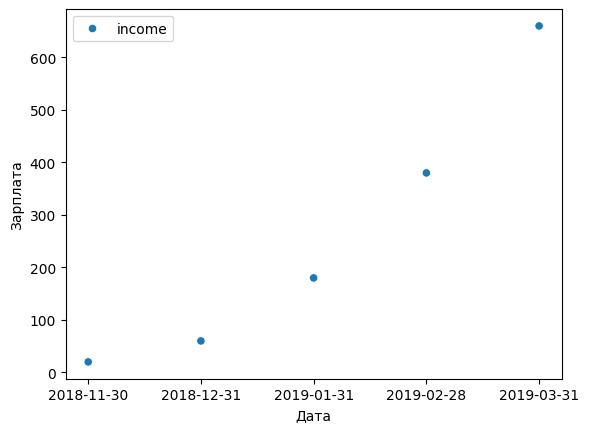

In [63]:
# 1.7 Визуализация, seaborn, почти также круто, как ggplot2
# Представьте, что у вас есть датафрэйм df, хранящий данные о зарплате за месяц, со всего 1-ой колонкой income.
# Укажите верные способы, как отрисовать простой график зависимости зарплаты от даты
#  (то, как отображается дата сейчас не важно, главное сам график)
import pandas as pd
import seaborn as sns


incomes = pd.read_csv('https://stepik.org/media/attachments/course/4852/income.csv')
ax = sns.scatterplot(data = incomes)
ax.set_xlabel('Дата')
ax.set_ylabel('Зарплата')




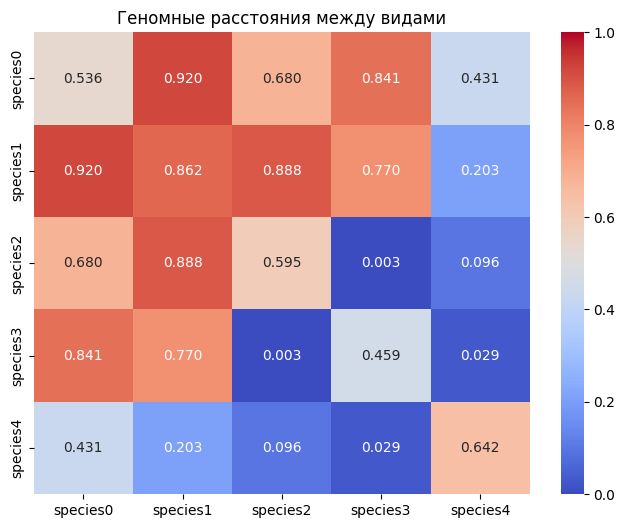

In [64]:
# 1.7 Визуализация, seaborn, почти также круто, как ggplot2
# Скачайте данные, представляющие геномные расстояния между видами, и постройте тепловую карту, чтобы различия было видно наглядно.
# В ответ впишите, какая картинка соответствует скачанным данным.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных (первый столбец становится индексом)
genom_matrix = pd.read_csv('https://stepik.org/media/attachments/course/4852/genome_matrix.csv', index_col=0)

# Построение тепловой карты
plt.figure(figsize=(8, 6))
sns.heatmap(genom_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.3f')
plt.title('Геномные расстояния между видами')
plt.show()



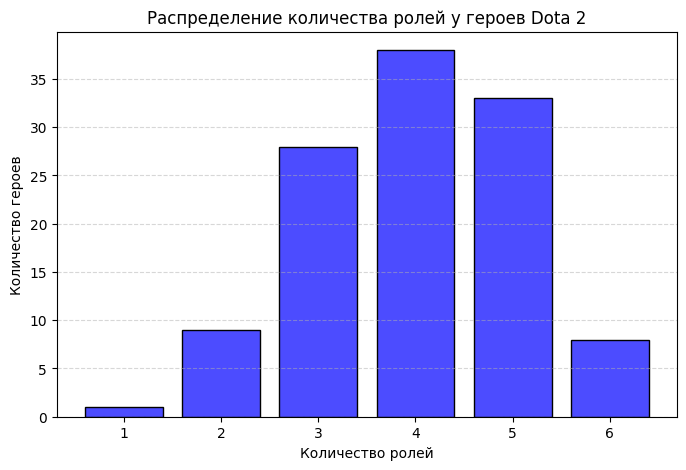


Наиболее часто встречающееся количество ролей: 4

Распределение количества ролей:
roles_count
1     1
2     9
3    28
4    38
5    33
6     8
Name: count, dtype: int64


In [65]:
# 1.7 Визуализация, seaborn, почти также круто, как ggplot2
# Пришло время узнать, кто самый главный рак какая роль в dota самая распространённая.
# Скачайте датасэт с данными о героях из игры dota 2 и посмотрите на распределение их возможных ролей
# в игре (колонка roles). Постройте гистограмму, отражающую скольким героям
# сколько ролей приписывается (по мнению Valve, конечно) и напишите какое число ролей у большинства героев.



import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

# 1. Загрузка данных
# Внимание: ссылку на файл нужно указать. В вашем проекте его можно загрузить локально.
df = pd.read_csv('https://stepik.org/media/attachments/course/4852/dota_hero_stats.csv')
# df = pd.read_csv('dota_hero_stats.csv')  # Пример локальной загрузки

# 2. Преобразование столбца 'roles' из строки в список
# Поскольку данные имеют особый формат (строка похожа на список), используем ast.literal_eval
df['roles_list'] = df['roles'].apply(ast.literal_eval)

# 3. Подсчет количества ролей для каждого героя
df['roles_count'] = df['roles_list'].apply(len)

# 4. Визуализация: гистограмма распределения
plt.figure(figsize=(8, 5))
sns.histplot(df['roles_count'], discrete=True, shrink=0.8, color='blue', alpha=0.7)
plt.title('Распределение количества ролей у героев Dota 2')
plt.xlabel('Количество ролей')
plt.ylabel('Количество героев')
plt.xticks(range(1, 7))  # Показываем все возможные значения
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 5. Определение моды (наиболее часто встречающегося значения)
mode_value = df['roles_count'].mode()[0]
print(f"\nНаиболее часто встречающееся количество ролей: {mode_value}")

# 6. Вывод распределения для проверки
print("\nРаспределение количества ролей:")
print(df['roles_count'].value_counts().sort_index())


   sepal_length  sepal_width  petal_length  petal_width species
1           5.1          3.5           1.4          0.2       0
2           4.9          3.0           1.4          0.2       0
3           4.7          3.2           1.3          0.2       0
4           4.6          3.1           1.5          0.2       0
5           5.0          3.6           1.4          0.2       0


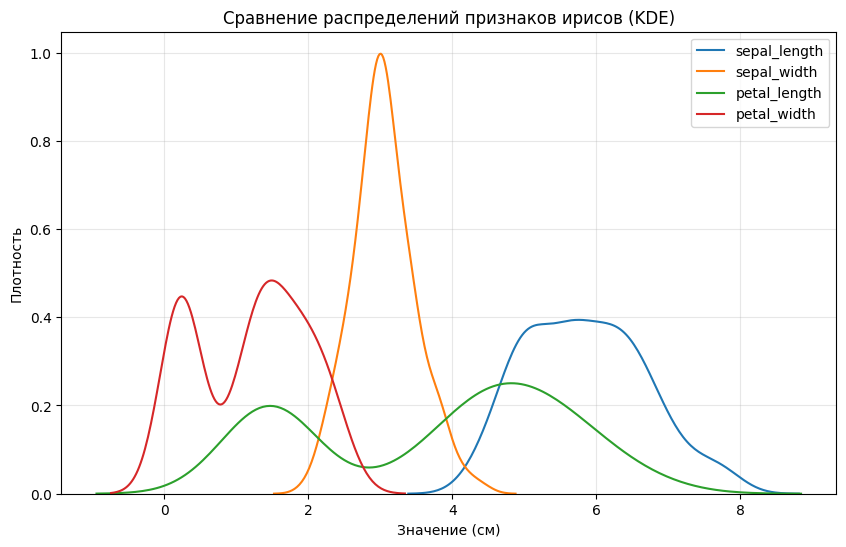

In [66]:
# 1.7 Визуализация, seaborn, почти также круто, как ggplot2

# Теперь перейдём к цветочкам. Магистрантка Адель решила изучить какие бывают ирисы.
# Помогите Адель узнать об ирисах больше - скачайте датасэт со значениями параметров ирисов,
# постройте их распределения и отметьте правильные утверждения, глядя на график.
# Распределение должно быть по всем образцам, без разделения на вид.


# Загружаем данные
# Параметры:
# - header=None: в файле нет строки с заголовками столбцов
# - names: задаём названия столбцов вручную
# - on_bad_lines='skip': пропускаем проблемные строки, если они есть
iris = pd.read_csv(
    'https://stepik.org/media/attachments/course/4852/iris.csv',
    header=None,
    names=['id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'],
    on_bad_lines='skip'
)

# Преобразуем числовые колонки в формат float (на случай, если какие-то значения пришли как строки)
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    iris[col] = pd.to_numeric(iris[col], errors='coerce')

# Удаляем строки с пропущенными значениями (если они появились из-за ошибок конвертации)
iris = iris.dropna().drop(columns=['id'])

# Выводим первые 5 строк, чтобы убедиться, что всё загрузилось правильно
print(iris.head())

# Построение всех KDE на одном графике
plt.figure(figsize=(10, 6))
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    sns.kdeplot(data=iris, x=col, label=col, fill=False, common_norm=False)

plt.title('Сравнение распределений признаков ирисов (KDE)')
plt.xlabel('Значение (см)')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

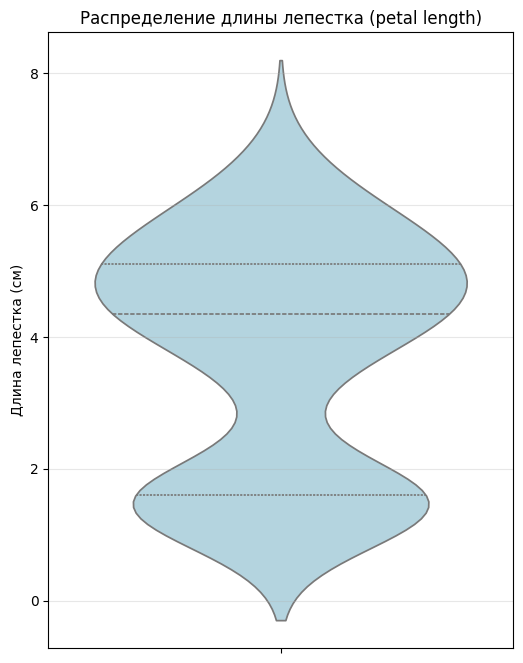

In [67]:

# 1.7 Визуализация, seaborn, почти также круто, как ggplot2

# Рассмотрим длину лепестков (petal length) подробнее и воспользуемся для этого violin плотом.
# Нарисуйте распределение длины лепестков ирисов из предыдущего датасэта
# с помощью violin плота и выберите правильный (такой же) вариант среди предложенных





# Данные iris уже загружены в переменную iris
plt.figure(figsize=(6, 8))
sns.violinplot(data=iris, y='petal_length', inner='quartile', color='lightblue')
plt.title('Распределение длины лепестка (petal length)')
plt.ylabel('Длина лепестка (см)')
plt.grid(axis='y', alpha=0.3)
plt.show()

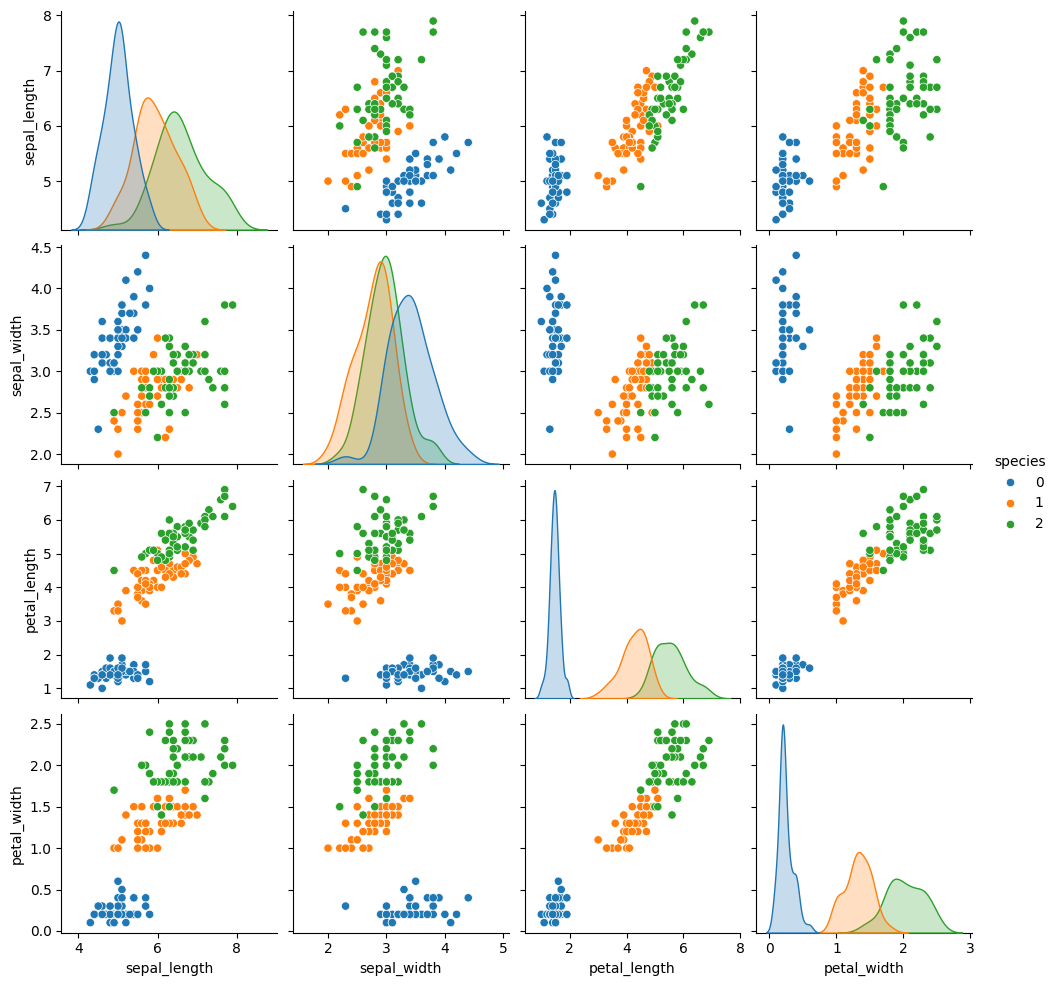

In [68]:

# 1.7 Визуализация, seaborn, почти также круто, как ggplot2
# Продолжаем изучение ирисов!
# Ещё один важный тип графиков - pairplot, отражающий зависимость пар переменных друг от друга,
# а также распределение каждой из переменных.
# Постройте его и посмотрите на scatter плоты для каждой из пар фичей.
# Какая из пар навскидку имеет наибольшую корреляцию?

# Также обратите внимание, что можно разделить на группы с помощью параметра hue.


sns.pairplot(iris, hue='species', diag_kind='kde', height=2.5)
plt.show()

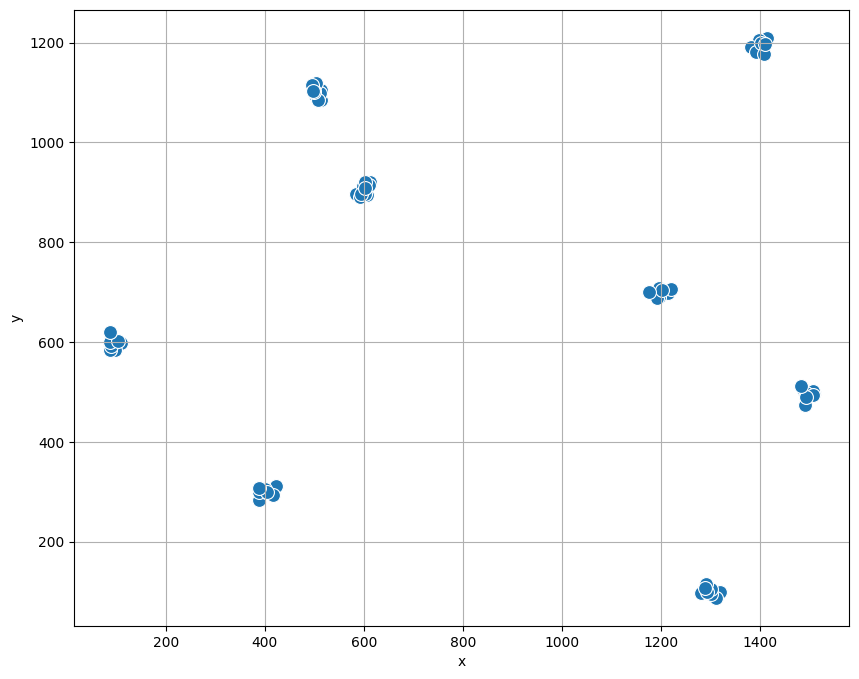

In [69]:
# 1.7 Визуализация, seaborn, почти также круто, как ggplot2

# Вам дан датасэт с 2-мя фичами (колонками). Постройте график распределения точек (наблюдений) в пространстве
# этих 2-ух переменных (одна из них будет x, а другая - y) и напишите число кластеров, формируемых наблюдениями.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io

# Вставляем твои данные
data = """x y
512.9288132567647 1084.3985600118858
1294.8284346732516 101.78481737971728
1318.4202978808864 99.07199508227433
100.53373977752827 601.802103900969
1413.460092296244 1209.6813449223562
1300.0242751424375 100.97971131736817
1213.983912268878 697.3394218979315
1183.1112622664268 698.5031954500848
500.9980005815503 1095.4153385148154
1394.3786474762935 1199.8277740305975
514.0691053301373 1104.1980482836152
1310.2725459463545 87.46638959357722
1280.726959250986 97.60655195523299
511.05650638929063 1098.6456507538326
1301.0396715785844 95.52984297413518
584.5214974428641 896.2784855893262
1194.8603812141891 689.9137218694077
1494.0021214008477 490.3873214468171
1488.735006473038 502.1709770044602
423.2788648539068 311.0492159619208
1199.4400782956304 705.2174431077938
387.75465329588945 307.6555658270581
507.0020443221399 1084.994406604098
1501.7288504684338 498.373918407721
87.30880028370126 596.5589794194319
401.20171902704544 301.87899187486846
1509.1514381449406 498.0038041279145
1506.5785665388062 501.2548360795437
502.3910454198707 1119.2914356174963
108.93458450018103 597.8612143776321
606.5933769952107 893.6059001301196
387.7190762429451 282.9248768386636
90.10085190930226 605.1400327101856
402.22570756474005 298.4273956569414
1401.3714920114091 1184.1503822631173
1300.9578484367596 104.91733892502657
1493.0521947728905 497.8372142378131
97.16887380555717 583.1749695826192
1290.9937529552913 114.95141885071395
591.7230839370814 890.5661036504418
599.0187622540968 913.486110833135
416.6003343822093 293.9579656587674
499.185061872034 1102.5613951465277
601.9245990220523 896.5922191370821
1405.1473635314303 1198.3680800228624
388.59922999643766 299.6479581733356
400.1580901803086 305.1942149927714
1397.2335969142673 1204.6592938502392
1506.0244055607495 494.15090400292434
87.90609202944978 583.2015544398306
1193.689697358149 702.2271961156877
89.60796144862832 592.2800388137766
611.4638876359409 920.5877278188257
499.6930551762512 1101.7191755469441
610.7189247413553 913.6310552808841
1490.0629858528362 474.2426631862053
1381.51415511764 1190.2592033924436
1195.4921253224366 708.8644335365798
403.63585906392575 298.86358659549546
594.4444451260324 896.9460766482036
1492.5651811860012 489.77906862606443
1390.7283120929073 1181.0708814013917
86.70886644436055 599.5299079200448
1401.426466550891 1199.173651043015
1407.8762397753183 1176.9738641618599
1219.1423552843312 706.9626463733359
1293.5110927616201 98.53714756937045
103.12478137386846 602.4737958753796
1483.28794623619 511.73996519251693
88.28683042369161 619.1225140663486
1192.5099125925815 687.8802675399718
495.73092097862923 1114.3653665004533
1287.7696277477257 106.70163865882004
1202.0951242934366 703.4367355258375
601.9145957071654 921.2130097506927
497.10630079537106 1103.5874834328342
1409.6928236789865 1196.4782804850286
602.3640785192046 909.0046166424083
1175.5508250509888 699.2259394436077
388.1110909214951 306.74507482476747

"""

# Читаем данные из строки
df = pd.read_csv(io.StringIO(data), sep=' ')

# Рисуем
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x', y='y', s=100)
plt.grid(True)
plt.show()


# 🧠 1.10 Stepik ML Contest — Реальный рабочий кейс

## 🎯 Что это?

Это финальный проект курса, максимально приближённый к задаче Data Scientist’а в продакшене. Ты получаешь сырые логи активности студентов на платформе и должен предсказать, дойдёт ли пользователь до конца курса.

## 📊 Суть задачи

Бинарная классификация (бросит / закончит) на основе анонимизированных данных о первых шагах на платформе. Метрика — ROC AUC.

## 🗃️ Исходные данные

- `event_data_train.zip` — события: просмотры, попытки решения, успехи.
- `submissions_data_train.zip` — детали отправок решений.

## 🛠️ Этапы работы (полный DS-цикл)

1. **Feature engineering** — агрегация логов в признаки (число попыток, время первого действия, средний интервал и т.д.).
2. **EDA и визуализация** — pandas, seaborn.
3. **Моделирование** — RandomForest, LightGBM, логистическая регрессия.
4. **Предсказание на тесте** и расчёт ROC AUC.

## ✅ Почему это ценно?

Это не абстрактное соревнование, а прототип реального проекта по удержанию пользователей. Навык, полученный здесь, можно сразу встроить в портфолио и использовать на собеседованиях.

> **Как сдавать**: обучаешь модель, предсказываешь для тестовой выборки, сохраняешь результат в CSV и загружаешь в систему Stepik (как заказчику). Автоматическая проверка — это просто упрощённая приёмка.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

events_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/event_data_train.zip')
events_data.head(10)


,step_id,timestamp,action,user_id
0,32815,1434340848,viewed,17632
1,32815,1434340848,passed,17632
2,32815,1434340848,discovered,17632
3,32811,1434340895,discovered,17632
4,32811,1434340895,viewed,17632
5,32811,1434340895,passed,17632
6,32929,1434340921,discovered,17632
7,32929,1434340921,viewed,17632
8,32929,1434340939,started_attempt,17632
9,32929,1434340944,passed,17632


# ⏱️ Колонка `timestamp`

**Что это?**  
Метка времени, показывающая, когда произошло событие (просмотр, клик, отправка решения).

**Форматы:**  
- Unix‑время (целое число секунд / миллисекунд от 01.01.1970)  
- Строка ISO (например, `2023-05-12 14:35:21`)

**Зачем нужна в анализе данных?**  
- Восстановить хронологию действий.  
- Вычислить продолжительности (время между событиями).  
- Создать признаки «время первого действия», «время последнего действия», «общее время активности».  
- Добавить циклические признаки (час суток, день недели).

**Как преобразовать в `pandas`?**  
```python
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [130]:
events_data.action.nunique()

4

In [72]:
events_data['date'] = pd.to_datetime(events_data.timestamp, unit='s')
events_data.head(10)
# events_data.dtypes

,step_id,timestamp,action,user_id,date
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48
1,32815,1434340848,passed,17632,2015-06-15 04:00:48
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35
5,32811,1434340895,passed,17632,2015-06-15 04:01:35
6,32929,1434340921,discovered,17632,2015-06-15 04:02:01
7,32929,1434340921,viewed,17632,2015-06-15 04:02:01
8,32929,1434340939,started_attempt,17632,2015-06-15 04:02:19
9,32929,1434340944,passed,17632,2015-06-15 04:02:24


In [73]:
events_data.date.min()
events_data.date.max()

Timestamp('2018-05-19 23:33:31')

In [74]:
events_data['day'] = events_data.date.dt.date
events_data.head()

,step_id,timestamp,action,user_id,date,day
0,32815,1434340848,viewed,17632,2015-06-15 04:00:48,2015-06-15
1,32815,1434340848,passed,17632,2015-06-15 04:00:48,2015-06-15
2,32815,1434340848,discovered,17632,2015-06-15 04:00:48,2015-06-15
3,32811,1434340895,discovered,17632,2015-06-15 04:01:35,2015-06-15
4,32811,1434340895,viewed,17632,2015-06-15 04:01:35,2015-06-15


In [75]:
events_data.groupby('day').user_id.nunique().head()

,user_id
day,
2015-06-15,705
2015-06-16,526
2015-06-17,440
2015-06-18,411
2015-06-19,377


<Axes: xlabel='day'>

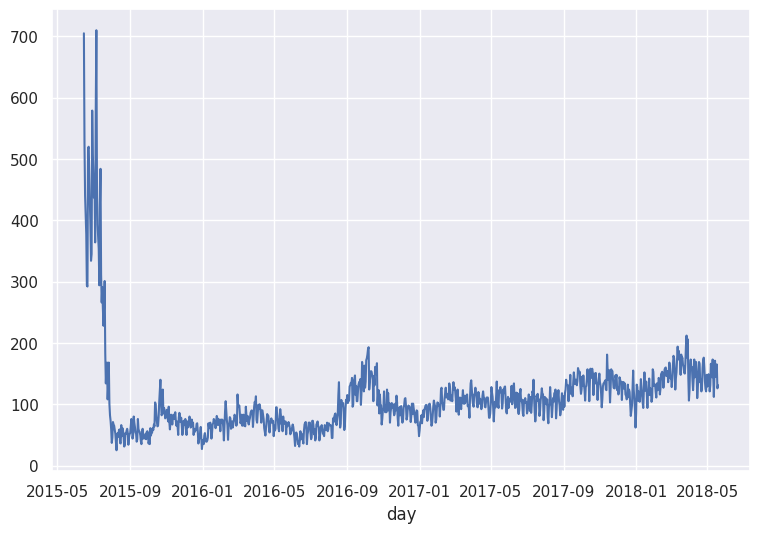

In [76]:
sns.set(rc={'figure.figsize': (9,6)})
events_data.groupby('day').user_id.nunique().plot()

In [77]:
#  Посчитаем пользователей у котрых action == passed (данное решение приводит к потере данных)
# а что если у пользователи количество passed = 0?

events_data[events_data['action'] == 'passed'] \
.groupby('user_id', as_index = False) \
.agg({'step_id': 'count'}).rename(columns={'step_id': 'passed_steps'}).head()

,user_id,passed_steps
0,2,9
1,3,87
2,5,11
3,7,1
4,8,84


array([[<Axes: title={'center': 'user_id'}>,
        <Axes: title={'center': 'passed_steps'}>]], dtype=object)

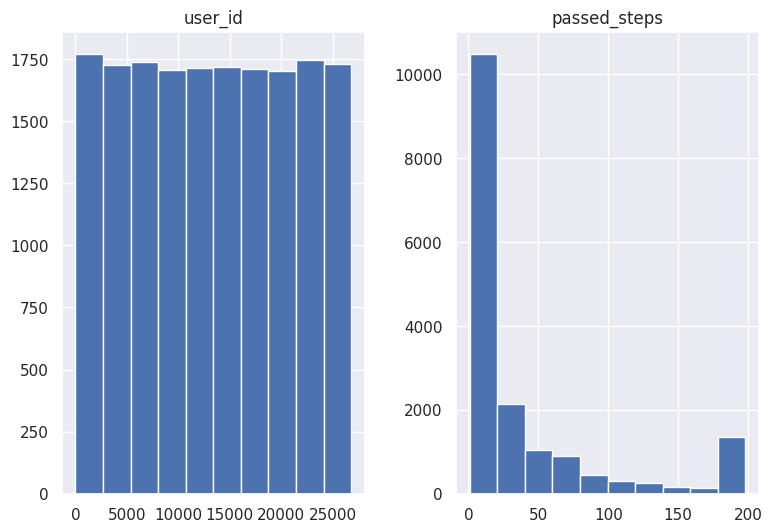

In [78]:
events_data[events_data['action'] == 'passed'] \
.groupby('user_id', as_index = False) \
.agg({'step_id': 'count'}).rename(columns={'step_id': 'passed_steps'}).hist()

In [79]:
# учтем тех, кто открыл курс, но не решил ни одного задания
events_data.pivot_table(index='user_id', columns = 'action',
                        values ='step_id',
                        aggfunc = 'count',
                        fill_value=0).reset_index().head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


<Axes: >

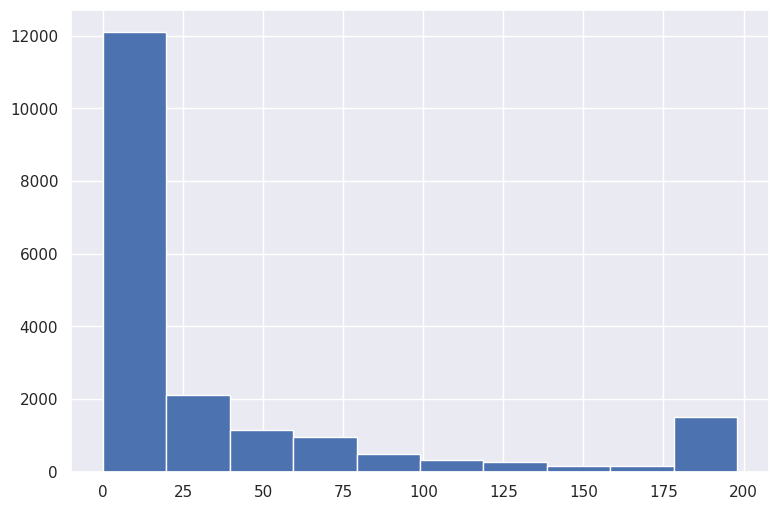

In [80]:
events_data.pivot_table(index='user_id', columns = 'action',
                        values ='step_id',
                        aggfunc = 'count',
                        fill_value=0).reset_index().discovered.hist()

# 📊 `pivot_table` — сводная таблица в pandas

## 🎯 Что делает?

Превращает «длинный» DataFrame в «широкий», агрегируя значения по указанным строкам и столбцам.  
Аналог сводных таблиц в Excel.

## 🔧 Основные параметры

| Параметр | Назначение |
|----------|------------|
| `values` | Колонка(и), значения которой будем агрегировать |
| `index`  | Строки итоговой таблицы (группировка по строкам) |
| `columns`| Столбцы итоговой таблицы (группировка по столбцам) |
| `aggfunc`| Функция агрегации (`'mean'`, `'sum'`, `'count'`, `'median'` и т.д.) |
| `fill_value`| Чем заменить пропуски (обычно `0`) |
| `margins`| Добавить итоговые строки/столбцы (`True`/`False`) |

## 📌 Пример (код для копирования)

```python
import pandas as pd

# Создаём пример данных
df = pd.DataFrame({
    'город': ['Москва', 'Москва', 'СПб', 'СПб', 'Москва'],
    'товар': ['А', 'Б', 'А', 'Б', 'А'],
    'продажи': [100, 150, 200, 50, 120]
})

# Строим сводную таблицу: города – строки, товары – столбцы, сумма продаж
pivot = pd.pivot_table(df, values='продажи', index='город', columns='товар',
                       aggfunc='sum', fill_value=0)
print(pivot)

In [81]:

submissions_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/submissions_data_train.zip')
submissions_data.head()


,step_id,timestamp,submission_status,user_id
0,31971,1434349275,correct,15853
1,31972,1434348300,correct,15853
2,31972,1478852149,wrong,15853
3,31972,1478852164,correct,15853
4,31976,1434348123,wrong,15853


In [82]:
submissions_data['date'] = pd.to_datetime(submissions_data.timestamp, unit='s')
submissions_data.head(10)

,step_id,timestamp,submission_status,user_id,date
0,31971,1434349275,correct,15853,2015-06-15 06:21:15
1,31972,1434348300,correct,15853,2015-06-15 06:05:00
2,31972,1478852149,wrong,15853,2016-11-11 08:15:49
3,31972,1478852164,correct,15853,2016-11-11 08:16:04
4,31976,1434348123,wrong,15853,2015-06-15 06:02:03
5,31976,1434348188,correct,15853,2015-06-15 06:03:08
6,31976,1478852055,correct,15853,2016-11-11 08:14:15
7,31977,1434347371,correct,15853,2015-06-15 05:49:31
8,31978,1434349981,correct,15853,2015-06-15 06:33:01
9,31979,1434446091,correct,15853,2015-06-16 09:14:51


In [83]:
user_scores = submissions_data.pivot_table(index = 'user_id',
                             columns = 'submission_status',
                             values ='step_id',
                             aggfunc = 'count',
                        fill_value=0).reset_index()
user_scores.head()

submission_status,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


In [84]:
# какой промежуток отсутсвия студента на курсе можно считать пороговым - говритть о том, что он больше  не вернется на курс

events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day']).head()

,user_id,day,timestamp
0,17632,2015-06-15,1434340848
36,12494,2015-06-15,1434341931
59,442,2015-06-15,1434342029
62,22254,2015-06-15,1434342042
94,6646,2015-06-15,1434342230


# 🧹 `drop_duplicates()` — удаление дубликатов строк

## 🎯 Что делает?

Удаляет повторяющиеся строки из DataFrame (или Series). По умолчанию оставляет **первое** вхождение, остальные удаляет.

## 🔧 Основные параметры

| Параметр | Назначение |
|----------|------------|
| `subset`  | Список колонок, по которым проверять дубликаты (по умолчанию все колонки) |
| `keep`    | `'first'` (оставить первую), `'last'` (оставить последнюю), `False` (удалить все дубликаты) |
| `inplace` | `True` – изменить исходный DataFrame, `False` – вернуть новый (по умолч.) |
| `ignore_index` | `True` – сбросить индекс после удаления |

## 📌 Пример (код для копирования)

```python
import pandas as pd

# Создаём DataFrame с дубликатами
df = pd.DataFrame({
    'id': [1, 2, 2, 3, 3, 3],
    'name': ['A', 'B', 'B', 'C', 'C', 'C'],
    'value': [10, 20, 20, 30, 30, 30]
})
print("Исходный:")
print(df)

# Удаляем полные дубликаты (все колонки)
df_unique = df.drop_duplicates()
print("\nПосле drop_duplicates():")
print(df_unique)

# Удаляем дубликаты только по колонке 'id'
df_unique_id = df.drop_duplicates(subset=['id'])
print("\nПосле drop_duplicates(subset=['id']):")
print(df_unique_id)

# Оставляем последнее вхождение
df_last = df.drop_duplicates(keep='last')
print("\nПосле drop_duplicates(keep='last'):")
print(df_last)

In [85]:
# отберем уникальные дни каждого студента в список (apply(list)), когда он был на курсе
events_data[['user_id', 'day', 'timestamp']].drop_duplicates(subset=['user_id', 'day'])\
.groupby('user_id')['timestamp'].apply(list).head()

,timestamp
user_id,
1,[1472827464]
2,"[1514383364, 1519226966]"
3,"[1434358476, 1441257725, 1441440209, 144153391..."
5,"[1466156809, 1499859621]"
7,[1521634660]


In [86]:
# найдем временные перерывы между днями каждого студента
gap_data = events_data[['user_id', 'day', 'timestamp']]\
.drop_duplicates(subset=['user_id', 'day']).groupby('user_id')['timestamp']\
.apply(np.diff)\
.values

print(type(gap_data))

<class 'numpy.ndarray'>


In [87]:
# Склеиваем все массивы в один плоский (gap_data уже массив массивов из-за .values)
all_diffs = np.concatenate(gap_data)

# Переводим секунды в дни
gap_days = pd.Series(all_diffs) / (24 * 60 * 60)
gap_days

,0
0,56.060208
1,79.852419
2,2.112083
3,1.084606
4,32.047106
...,...
97867,166.056586
97868,5.845613
97869,1.137176
97870,0.659942


# 🐍 Метод `.apply(list)` в pandas

## 🎯 Что делает?

Преобразует значения в каждой группе (или в каждой строке/столбце) в **список Python**.

Чаще всего используется после `groupby()`:  
- Собирает все значения из одной группы в обычный список.
- Позволяет затем применять функции, работающие со списками (например, `np.diff`, `len`, `sum` и т.д.).

## 📌 Базовый синтаксис

```python
df.groupby('группа')['колонка'].apply(list)

<Axes: >

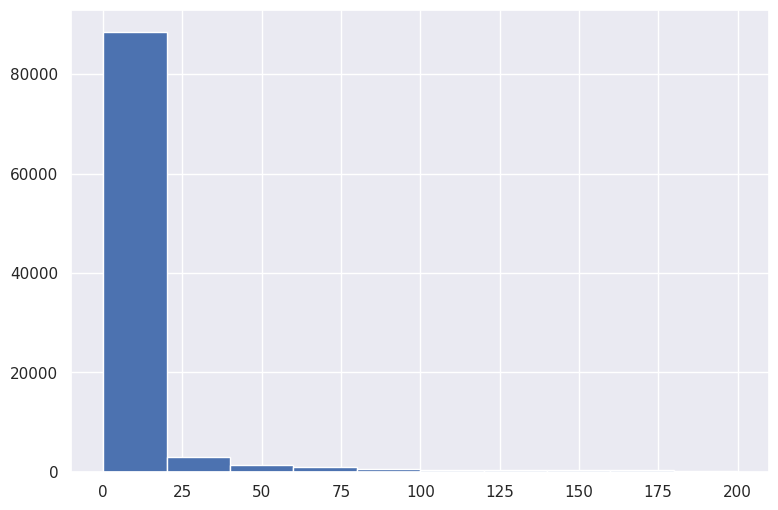

In [88]:
gap_days[gap_days < 200].hist()

In [89]:
# 95-й квантиль (95% значений левее этой точки)
gap_days.quantile(0.95)
# только 5% студентов возвращается на курс после перерыва в 2 месяца (59.760440972222156 = 2 месяца)

np.float64(59.760440972222156)

In [90]:
gap_days.quantile(0.90)

np.float64(18.325995370370403)

In [91]:
# будем считать, что если человека нет на курсе 30 дней и у него нет сертификата, значит он больше не вернется
events_data.tail()

,step_id,timestamp,action,user_id,date,day
3480698,33375,1526772685,viewed,11677,2018-05-19 23:31:25,2018-05-19
3480699,32815,1526772750,viewed,5198,2018-05-19 23:32:30,2018-05-19
3480700,32815,1526772750,discovered,5198,2018-05-19 23:32:30,2018-05-19
3480701,32815,1526772750,passed,5198,2018-05-19 23:32:30,2018-05-19
3480702,33892,1526772811,viewed,18526,2018-05-19 23:33:31,2018-05-19


In [92]:
events_data.groupby('user_id', as_index=False)\
.agg({'timestamp': 'max'}).head()

,user_id,timestamp
0,1,1472827464
1,2,1519226966
2,3,1444581588
3,5,1499859939
4,7,1521634660


In [93]:
# чему равен timestamp одного месяца
30 * 24 * 60 * 60

2592000

In [94]:
# рассчитаем сколько прошло с момента последнего посещения на текущий день (2018-05-19)
user_data = events_data.groupby('user_id', as_index=False)\
.agg({'timestamp': 'max'}).rename(columns={'timestamp': 'last_timestamp'})

In [95]:
user_data.head()

,user_id,last_timestamp
0,1,1472827464
1,2,1519226966
2,3,1444581588
3,5,1499859939
4,7,1521634660


In [97]:
now = 1526772811	# 2018-05-19 23:33:31	2018-05-19 (конец нашей таблицы)

drop_out_threshold = 2592000 # 30 дней
user_data['is_gone_user'] = (now - user_data.last_timestamp) > drop_out_threshold

In [98]:
user_data.head()

,user_id,last_timestamp,is_gone_user
0,1,1472827464,True
1,2,1519226966,True
2,3,1444581588,True
3,5,1499859939,True
4,7,1521634660,True


In [99]:
user_scores.head()

submission_status,user_id,correct,wrong
0,2,2,0
1,3,29,23
2,5,2,2
3,8,9,21
4,14,0,1


In [100]:
info = user_data.merge(user_scores, on = 'user_id' , how = 'outer')

In [101]:
info.head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,1,1472827464,True,NaN,NaN
1,2,1519226966,True,2.0,0.0
2,3,1444581588,True,29.0,23.0
3,5,1499859939,True,2.0,2.0
4,7,1521634660,True,NaN,NaN


In [102]:
info.fillna(0)

,user_id,last_timestamp,is_gone_user,correct,wrong
0,1,1472827464,True,0.0,0.0
1,2,1519226966,True,2.0,0.0
2,3,1444581588,True,29.0,23.0
3,5,1499859939,True,2.0,2.0
4,7,1521634660,True,0.0,0.0
...,...,...,...,...,...
19229,26790,1517495987,True,1.0,0.0
19230,26793,1510225034,True,0.0,0.0
19231,26794,1512035039,True,33.0,9.0
19232,26797,1509995096,True,2.0,0.0


In [103]:
# если не использовать how = 'outer' можно потерять данные
user_data.merge(user_scores).head()

,user_id,last_timestamp,is_gone_user,correct,wrong
0,2,1519226966,True,2,0
1,3,1444581588,True,29,23
2,5,1499859939,True,2,2
3,8,1481466913,True,9,21
4,14,1436368676,True,0,1


# 🔗 `merge` — объединение DataFrame

## 🎯 Зачем нужен?

Соединяет два DataFrame по общему столбцу или индексу (как JOIN в SQL).  
Используется, когда нужно подтянуть данные из одной таблицы в другую.

## 🧩 Основные параметры

| Параметр | Назначение |
|----------|------------|
| `left` / `right` | Левый и правый DataFrame |
| `how` | Тип соединения (`'inner'`, `'outer'`, `'left'`, `'right'`) |
| `on` | Имя столбца (или список), по которому соединяем (если одинаковое название) |
| `left_on` / `right_on` | Разные имена столбцов для соединения |
| `suffixes` | Суффиксы для одинаковых столбцов (по умолчанию `('_x', '_y')`) |

## 📌 Пример

```python
import pandas as pd

df1 = pd.DataFrame({
    'user_id': [1, 2, 3],
    'name': ['Alice', 'Bob', 'Charlie']
})

df2 = pd.DataFrame({
    'user_id': [2, 3, 4],
    'salary': [50000, 60000, 70000]
})

# INNER JOIN (только совпадающие user_id)
merged = pd.merge(df1, df2, on='user_id', how='inner')
print(merged)

In [104]:
user_events_data = events_data.pivot_table(index='user_id', columns = 'action',
                        values ='step_id',
                        aggfunc = 'count',
                        fill_value=0).reset_index()

In [105]:
user_events_data.head()

action,user_id,discovered,passed,started_attempt,viewed
0,1,1,0,0,1
1,2,9,9,2,10
2,3,91,87,30,192
3,5,11,11,4,12
4,7,1,1,0,1


In [112]:
info = info.merge(user_events_data, how='outer')


In [113]:
info.head()
info.fillna(0)


,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed
0,1,1472827464,True,0.0,0.0,1,0,0,1
1,2,1519226966,True,2.0,0.0,9,9,2,10
2,3,1444581588,True,29.0,23.0,91,87,30,192
3,5,1499859939,True,2.0,2.0,11,11,4,12
4,7,1521634660,True,0.0,0.0,1,1,0,1
...,...,...,...,...,...,...,...,...,...
19229,26790,1517495987,True,1.0,0.0,8,8,1,9
19230,26793,1510225034,True,0.0,0.0,1,0,1,1
19231,26794,1512035039,True,33.0,9.0,69,69,34,180
19232,26797,1509995096,True,2.0,0.0,10,10,2,13


In [115]:
# сколько уникальных дней студент был на курсе
user_days = events_data.groupby('user_id').day.nunique()
user_days.reset_index().head()

,user_id,day
0,1,1
1,2,2
2,3,7
3,5,2
4,7,1


In [119]:
# добавим эту информацию в info
info = info.merge(user_days, on = 'user_id', how = 'outer')
info.head()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day
0,1,1472827464,True,NaN,NaN,1,0,0,1,1
1,2,1519226966,True,2.0,0.0,9,9,2,10,2
2,3,1444581588,True,29.0,23.0,91,87,30,192,7
3,5,1499859939,True,2.0,2.0,11,11,4,12,2
4,7,1521634660,True,NaN,NaN,1,1,0,1,1


In [120]:
# сравним количество студентов до и после преобразований, убедимся что все даннеы на месте
info.user_id.nunique()


19234

In [121]:
events_data.user_id.nunique()
#все верно!

19234

In [127]:
# обозначим тех, кто закончил курс (условие: студент набрал больше 175 баллов)
info['passed_scores'] = info.passed > 170


In [128]:
info.groupby('passed_scores').count()

,user_id,last_timestamp,is_gone_user,correct,wrong,discovered,passed,started_attempt,viewed,day
passed_scores,,,,,,,,,,
False,17809,17809,17809,8515,8515,17809,17809,17809,17809,17809
True,1425,1425,1425,1425,1425,1425,1425,1425,1425,1425


In [129]:
print(f'Процент студентов, закончивших курс = {1425/17809	* 100}')

Процент студентов, закончивших курс = 8.001572238755687
